In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

In [23]:
retr_df = pd.read_csv("retrieval_metrics.csv").round(2)
ragas_df = pd.read_csv("ragas_results.csv").round(2)
display(retr_df.head(2))
display(ragas_df.head(2))

,Hit@10,Hit@3,Hit@6,MAP@10,MRR,NDCG@10,NDCG@3,NDCG@6,P@10,P@3,P@6,R@10,R@3,R@6
0,1.0,1.0,1.0,0.95,0.95,0.97,0.97,0.97,0.23,0.33,0.23,1.0,1.0,1.0


,user_input,retrieved_contexts,response,reference,context_precision,context_recall,faithfulness,answer_relevancy
0,Which NGO focuses on foundational literacy and...,"[""Page 1 of 2\nPratham Education Foundation\nE...",Pratham Education Foundation,Pratham focuses on foundational literacy and n...,NaN,1.0,1.0,0.59
1,Which NGO runs programs for girls' education i...,"[""reliable estimates of children's schooling s...",Goonj,Pratham runs programs that support girls' educ...,NaN,0.0,1.0,0.54


### Retrieval metrics
- Precision@k measures the fraction of the top $k$ retrieved items that are relevant, defined as $$ \text{P@}k = \frac{\text{relevant in top }k}{k} $$, so higher means less noise in the first $k$ results.
- Recall@k measures coverage of relevant items in the top $k$, defined as $$ \text{R@}k = \frac{\text{relevant in top }k}{\text{total relevant}} $$, so higher means the retriever didn’t miss evidence needed to answer.
- Hit@k is 1 if any relevant item appears in the top $k$ and 0 otherwise, making it a simple “did we get at least one good hit” indicator for the first $k$ results.
- MRR averages the reciprocal of the rank of the first relevant result across queries, $$ \text{MRR}=\frac{1}{N}\sum_{i=1}^{N} \frac{1}{\text{rank}_i} $$, rewarding systems that surface a relevant item very early.
- MAP@k averages the precision at each relevant hit position up to $k$ across queries, rewarding systems that return many relevant items ranked near the top.
- NDCG@k is a graded-relevance metric that discounts gains by rank position up to $k$, so higher means more relevant items ranked earlier rather than later.

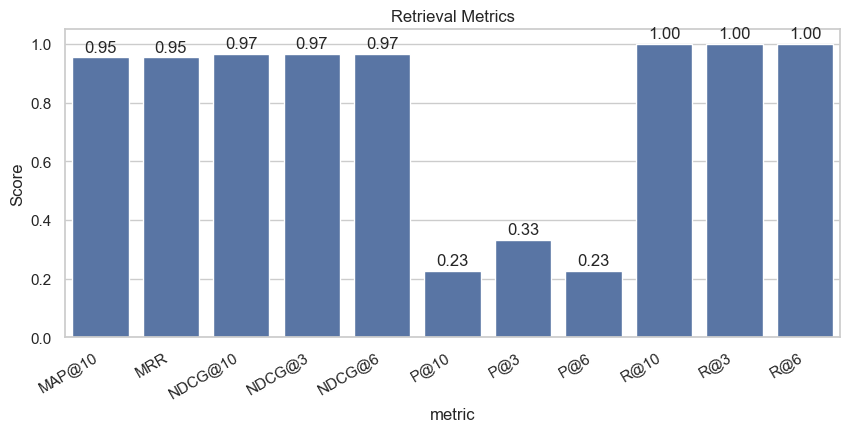

In [19]:
# Select common retrieval metrics
keep_cols = [c for c in retr_df.columns if any(x in c for x in ["P@", "R@", "NDCG@", "MRR", "MAP@"])]
retr_long = retr_df[keep_cols].melt(var_name="metric", value_name="score")

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=retr_long, x="metric", y="score", color="#4C72B0")
ax.set_ylim(0, 1.05)
ax.set_title("Retrieval Metrics")
ax.set_ylabel("Score")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2)
plt.xticks(rotation=30, ha="right")
plt.show()


### RAGAS metrics
- Faithfulness measures how factually consistent the answer is with the retrieved context, scoring 1.0 when all claims in the answer are supported by the provided passages.
- Answer relevancy measures how well the answer addresses the user question, capturing topical alignment and responsiveness rather than factual grounding alone.
- Context precision measures how much of the retrieved context is actually relevant to answering the question, so higher precision means less distracting or off-topic text in the prompt.
- Context recall measures whether the retrieved context contains all key information needed to produce the ideal answer, so higher recall means the retriever didn’t omit necessary evidence.

,metric,score
0,context_precision,0.700000
1,context_recall,0.818182
2,faithfulness,0.975000
3,answer_relevancy,0.538436


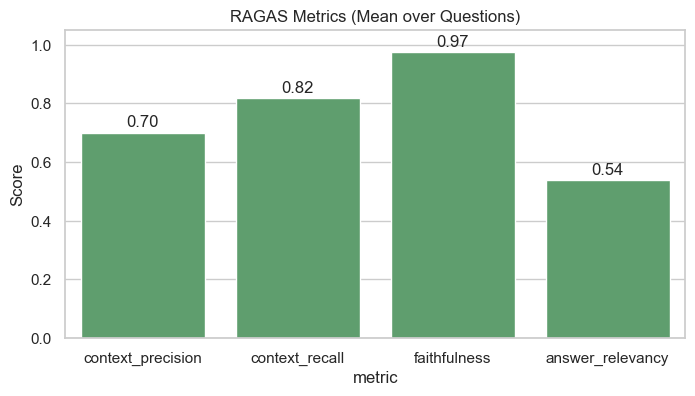

In [20]:
ragas_metric_cols = [c for c in ragas_df.columns if c in [
    "faithfulness", "answer_relevancy", "context_precision", "context_recall"
]]
ragas_means = ragas_df[ragas_metric_cols].mean().reset_index()
ragas_means.columns = ["metric", "score"]
display(ragas_means)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=ragas_means, x="metric", y="score", color="#55A868")
ax.set_ylim(0, 1.05)
ax.set_title("RAGAS Metrics (Mean over Questions)")
ax.set_ylabel("Score")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2)
plt.xticks(rotation=0)
plt.show()


In [21]:
cols = ["user_input", "faithfulness", "answer_relevancy", "context_precision", "context_recall"]
display(ragas_df[cols].sort_values("answer_relevancy", ascending=True))


,user_input,faithfulness,answer_relevancy,context_precision,context_recall
7,Which NGO runs rural health outreach programs?,NaN,0.000000,0.0,0.0
4,Which NGO supports health and nutrition for ch...,1.00,0.489727,NaN,1.0
9,Which NGO is focused on tree planting and refo...,1.00,0.537835,1.0,1.0
1,Which NGO runs programs for girls' education i...,1.00,0.541223,NaN,0.0
5,Which NGO focuses on elderly care services in ...,1.00,0.571228,NaN,1.0
3,Which NGO works on child rights and improving ...,0.75,0.588157,NaN,1.0
0,Which NGO focuses on foundational literacy and...,1.00,0.594057,NaN,1.0
8,Which NGO supports maternal and child health i...,1.00,0.617549,1.0,1.0
6,Which NGO provides healthcare support for seni...,1.00,0.621669,1.0,1.0
2,Which NGO offers youth skilling or employabili...,1.00,0.636551,NaN,1.0


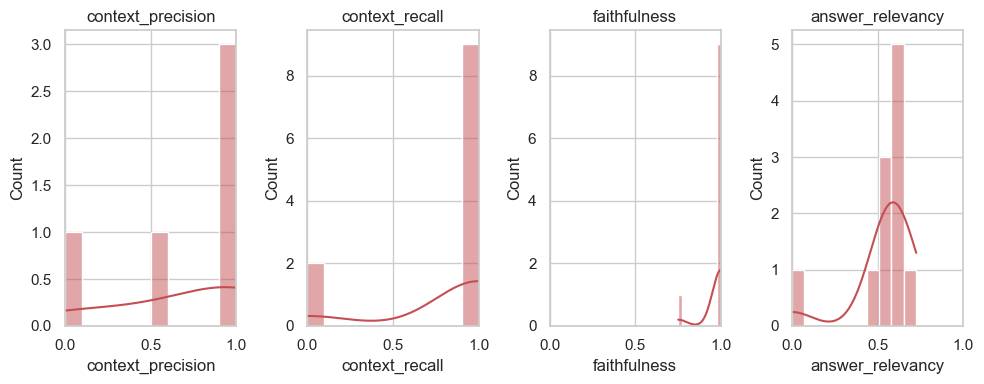

In [22]:
plt.figure(figsize=(10, 4))
for i, col in enumerate(ragas_metric_cols, 1):
    plt.subplot(1, len(ragas_metric_cols), i)
    sns.histplot(ragas_df[col], bins=10, kde=True, color="#C44E52")
    plt.title(col)
    plt.xlim(0, 1)
plt.tight_layout()
plt.show()


### How to read your results
- Very high Recall@k, Hit@k, MRR, MAP@10, and NDCG@k indicate the retriever is consistently surfacing at least one correct document near the top and ranking it well, which sets the generator up for success.
- High faithfulness means the model is staying grounded in the retrieved text with minimal hallucination, which is critical for trustworthy answers in RAG systems.
- If answer relevancy trails faithfulness, it often means the answer is grounded but could be better targeted to the phrasing or intent of the user’s query.
- If context precision lags, you are retrieving extra irrelevant text; if context recall lags, you are missing key evidence that the generator needs to answer fully.
